In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', 50)

In [ ]:
import os
print(os.path.getsize('/content/twcs.csv') / (1024**2), "MB")

492.5810251235962 MB


In [ ]:
df = pd.read_csv('/content/twcs.csv')
df.head()

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3,5.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0


In [ ]:
df.shape

(2811774, 7)

In [ ]:
df.columns

Index(['tweet_id', 'author_id', 'inbound', 'created_at', 'text',
       'response_tweet_id', 'in_response_to_tweet_id'],
      dtype='object')

In [ ]:
# Overall dimensions
print(f"Total rows: {len(df)}")
print(f"Total columns: {df.shape[1]}")

# Check each column
print("\nNull counts:")
print(df.isnull().sum())

# Breakdown by inbound
print("\nInbound vs Outbound:")
print(df['inbound'].value_counts())

Total rows: 2811774
Total columns: 7

Null counts:
tweet_id                         0
author_id                        0
inbound                          0
created_at                       0
text                             0
response_tweet_id          1040629
in_response_to_tweet_id     794335
dtype: int64

Inbound vs Outbound:
inbound
True     1537843
False    1273931
Name: count, dtype: int64


In [ ]:
# Look at a few raw rows
print("Customer tweet (inbound=True):")
print(df[df['inbound'] == True].iloc[0][['tweet_id', 'text', 'inbound']])

print("\nCompany reply (inbound=False):")
print(df[df['inbound'] == False].iloc[0][['tweet_id', 'text', 'inbound']])

# Sample 5 random customer tweets to see what we're working with
print("\n5 Random Customer Tweets:")
for i, row in df[df['inbound'] == True].sample(5, random_state=42).iterrows():
    print(f"  {row['text'][:100]}...")  # First 100 chars

Customer tweet (inbound=True):
tweet_id                                                2
text        @sprintcare and how do you propose we do that
inbound                                              True
Name: 1, dtype: object

Company reply (inbound=False):
tweet_id                                                    1
text        @115712 I understand. I would like to assist y...
inbound                                                 False
Name: 0, dtype: object

5 Random Customer Tweets:
  @AppleSupport Basically for a chat to be opened from call log, the message app should be opened/runn...
  @AppleSupport iOS 11.02 and Watchos4.0: No icon for Twitter notifications. Restart of iphone/watch, ...
  Dear god not again,@AppleSupport https://t.co/5Zf0Mnd6SI...
  @ATVIAssist Hi there! If I buy Call of Duty WWII on steam today, do I have instant access to the ope...
  Hi @Safaricom_Care why can't I pay my my Dstv texts says the Org is unavailable...


**Now check how many inbound tweets are likely thread starters versus follow-ups**




In [ ]:
customer_df = df[df["inbound"] == True].copy()

print("Total customer tweets:", len(customer_df))
print("Customer tweets starting a thread:", customer_df["in_response_to_tweet_id"].isna().sum())
print("Customer tweets that are replies/follow-ups:", customer_df["in_response_to_tweet_id"].notna().sum())

starter_pct = customer_df["in_response_to_tweet_id"].isna().mean() * 100
followup_pct = customer_df["in_response_to_tweet_id"].notna().mean() * 100

print(f"Starter tweets: {starter_pct:.2f}%")
print(f"Follow-up tweets: {followup_pct:.2f}%")

Total customer tweets: 1537843
Customer tweets starting a thread: 787346
Customer tweets that are replies/follow-ups: 750497
Starter tweets: 51.20%
Follow-up tweets: 48.80%


**Then inspect examples of follow-up customer tweets:**

In [ ]:
followups = customer_df[customer_df["in_response_to_tweet_id"].notna()]

for _, row in followups.sample(5, random_state=42).iterrows():
    print(row["text"])
    print("-" * 80)

@AdobeCare Can't reproduce it - yesterday Library and Film Strip weren't in sync, today they are.  Will take shots if it happens again.
--------------------------------------------------------------------------------
@AmericanAir It took almost an hour to “clean” the plane. We are boarding now.
--------------------------------------------------------------------------------
@AmericanAir Its says so but the kind ladies here have no idea of what's going on.
--------------------------------------------------------------------------------
@NikeSupport Mmmm es iphone... cómo borro cache y cookies??
--------------------------------------------------------------------------------
@JetBlue Okay. Thanks @521112 read above
--------------------------------------------------------------------------------


In [ ]:
# Work only with clean thread starters from now on
tickets = df[
    (df["inbound"] == True) &
    (df["in_response_to_tweet_id"].isna())
].copy()

print(f"Clean ticket candidates: {len(tickets)}")

# Add length features
tickets["text_length"] = tickets["text"].str.len()
tickets["word_count"] = tickets["text"].str.split().str.len()

print("\nCharacter length stats:")
print(tickets["text_length"].describe())

print("\nWord count stats:")
print(tickets["word_count"].describe())

# Count very short tickets
very_short = (tickets["word_count"] < 4).sum()
print(f"\nTweets with fewer than 4 words: {very_short} ({100*very_short/len(tickets):.1f}%)")

Clean ticket candidates: 787346

Character length stats:
count    787346.000000
mean        119.773308
std          51.882585
min           1.000000
25%          84.000000
50%         120.000000
75%         140.000000
max         328.000000
Name: text_length, dtype: float64

Word count stats:
count    787346.000000
mean         20.372294
std           9.747470
min           1.000000
25%          14.000000
50%          20.000000
75%          25.000000
max         137.000000
Name: word_count, dtype: float64

Tweets with fewer than 4 words: 14378 (1.8%)


In [ ]:
import re
import html

cleaned_tickets = tickets.copy()

# Remove very short, low-information tickets
cleaned_tickets = cleaned_tickets[cleaned_tickets["word_count"] >= 4].copy()

def clean_text(t):
    t = html.unescape(str(t))
    t = re.sub(r"http\S+|www\.\S+", " ", t)          # remove urls
    t = re.sub(r"@\w+", " ", t)                      # remove @mentions
    t = re.sub(r"#\w+", " ", t)                      # remove hashtags
    t = re.sub(r"\s+", " ", t).strip()               # normalize whitespace
    return t

cleaned_tickets["clean_text"] = cleaned_tickets["text"].apply(clean_text)

# Drop rows that become empty after cleaning
cleaned_tickets = cleaned_tickets[cleaned_tickets["clean_text"].str.len() > 0].copy()

print("Rows after short-text filter + cleaning:", len(cleaned_tickets))
print("Dropped rows:", len(tickets) - len(cleaned_tickets))
print("Drop percentage:", round((len(tickets)-len(cleaned_tickets))/len(tickets)*100, 2), "%")

print("\nSample cleaned rows:")
sample = cleaned_tickets.sample(5, random_state=42)[["text", "clean_text"]]
for i, row in sample.iterrows():
    print("RAW   :", row["text"])
    print("CLEAN :", row["clean_text"])
    print("-" * 100)

Rows after short-text filter + cleaning: 772532
Dropped rows: 14814
Drop percentage: 1.88 %

Sample cleaned rows:
RAW   : @AskAmex I’m locked out of my account and don’t have my card number. What can I do?
CLEAN : I’m locked out of my account and don’t have my card number. What can I do?
----------------------------------------------------------------------------------------------------
RAW   : @Safaricom_Care I sent exam inquiry through my brother's line 0799052212(Elly Ooko Achieng)and no results were received and no refund has been made.When is the refund reaching his line?
CLEAN : I sent exam inquiry through my brother's line 0799052212(Elly Ooko Achieng)and no results were received and no refund has been made.When is the refund reaching his line?
----------------------------------------------------------------------------------------------------
RAW   : Hey @115858. The iPhone X is cool and all, but why are random keyboard letters not working when responding to a text from the loc

In [ ]:
# Import the tool that converts text into count-based word/phrase features.
from sklearn.feature_extraction.text import CountVectorizer

# Import pandas so we can store and sort the phrase counts in a table.
import pandas as pd

# Take a random sample of 120,000 cleaned ticket texts so the exploration runs faster.
sample_text = cleaned_tickets["clean_text"].sample(120000, random_state=42)

# Create a vectorizer object that will count words and phrases in the sampled text.
vec = CountVectorizer(
    # Convert all text to lowercase before counting so "Refund" and "refund" are treated the same.
    lowercase=True,

    # Remove common English words like "the", "is", and "and" because they are not useful for urgency analysis.
    stop_words="english",

    # Count single words, two-word phrases, and three-word phrases.
    ngram_range=(1, 3),

    # Ignore n-grams that appear in fewer than 20 sampled tickets because they are too rare/noisy.
    min_df=20,

    # Ignore n-grams that appear in more than 60% of sampled tickets because they are too common to be useful.
    max_df=0.6
)

# Learn the vocabulary from the sample and turn the text into a sparse count matrix.
X = vec.fit_transform(sample_text)

# Sum each column of the count matrix to get the total frequency of each word/phrase across the sample.
freq = X.sum(axis=0).A1

# Get the actual text of each learned word/phrase in the same order as the columns in X.
terms = vec.get_feature_names_out()

# Create a pandas DataFrame with two columns: the word/phrase itself and its total count.
ngram_freq = pd.DataFrame({
    "term": terms,
    "count": freq
})

# Sort the table so the most frequent words/phrases appear first.
ngram_freq = ngram_freq.sort_values("count", ascending=False)

# Print the top 60 most frequent words/phrases in the sampled tickets.
print(ngram_freq.head(100))

          term  count
3851      just   9174
6268   service   8618
3292      help   8510
5236     phone   6822
7023      time   6293
...        ...    ...
5765  received   1544
1015    bought   1538
2449     error   1528
7113      told   1525
3281     hello   1521

[100 rows x 2 columns]


In [ ]:
# Import the regular expression library so we can search for phrases inside text.
import re

# Create a first-pass list of candidate urgency phrases that may indicate higher priority tickets.
candidate_phrases = [
    "account locked",
    "locked out",
    "cannot login",
    "cant login",
    "not working",
    "payment failed",
    "charged twice",
    "refund not received",
    "fraud",
    "hacked",
    "stolen",
    "service down",
    "outage",
    "app crashed",
    "error",
    "refund",
    "cancel",
    "urgent",
    "asap"
]

# Convert all cleaned ticket text to lowercase so phrase matching is case-insensitive.
text_series = cleaned_tickets["clean_text"].str.lower()

# Create an empty list where we will store the results for each phrase.
rows = []

# Loop through each candidate phrase one by one.
for phrase in candidate_phrases:
    # Escape the phrase so special regex characters are treated as normal text.
    pattern = re.escape(phrase)

    # Count how many cleaned tickets contain this phrase.
    count = text_series.str.contains(pattern, regex=True, na=False).sum()

    # Store the phrase, its raw count, and its percentage of the full cleaned dataset.
    rows.append({
        "phrase": phrase,
        "count": int(count),
        "pct": 100 * count / len(cleaned_tickets)
    })

# Turn the collected results into a DataFrame.
phrase_stats = pd.DataFrame(rows)

# Sort the phrases from most common to least common.
phrase_stats = phrase_stats.sort_values("count", ascending=False)

# Print the final phrase frequency table.
print(phrase_stats)

                 phrase  count       pct
16               cancel  23555  3.049065
15               refund  12935  1.674364
14                error  10292  1.332243
12               outage   5369  0.694987
4           not working   5158  0.667675
18                 asap   4163  0.538877
8                 fraud   2724  0.352607
17               urgent   1670  0.216172
9                hacked   1648  0.213324
10               stolen   1171  0.151579
1            locked out    604  0.078184
6         charged twice    545  0.070547
11         service down    276  0.035727
2          cannot login     92  0.011909
3            cant login     82  0.010614
13          app crashed     76  0.009838
5        payment failed     44  0.005696
0        account locked     37  0.004789
7   refund not received      8  0.001036


In [ ]:
# Import the regular expression library so we can search for phrases in text.
import re

# Choose the phrases we want to inspect more carefully in real ticket examples.
phrases_to_inspect = [
    "cancel",
    "refund",
    "error",
    "not working",
    "asap",
    "urgent",
    "fraud",
    "hacked",
    "locked out",
    "outage"
]

# Loop through each phrase one by one.
for phrase in phrases_to_inspect:
    # Print a clear section header so the examples are easy to read.
    print(f"\n{'='*30} PHRASE: {phrase} {'='*30}")

    # Escape the phrase so it is treated as plain text in the search.
    pattern = re.escape(phrase)

    # Filter the cleaned tickets to rows whose cleaned text contains this phrase.
    matches = cleaned_tickets[
        cleaned_tickets["clean_text"].str.lower().str.contains(pattern, regex=True, na=False)
    ]

    # Print how many matches were found for this phrase.
    print(f"Total matches: {len(matches)}")

    # Show 5 random example tickets for manual inspection.
    sample_matches = matches.sample(min(5, len(matches)), random_state=42)

    # Print each matched example.
    for text in sample_matches["clean_text"]:
        print("-", text)


============================== PHRASE: cancel ==============================
Total matches: 23555
- I cancelled my booking ONLINE within 24 hours of booking as per customer representative guidance, but didn't get the full refund.
- My issue was not resolved per my initial request. I did not make a request for a ride and was charged a cancellation fee. I am not surw if there is/was a in the app. However, I did not call for an ride this morning.
- I still havent received my paypal refund 5 days later from your cancelled order. Are you ever going to respond to my tweets?????
- Guess I won't make dinner with my girlfriend :( thanks to a cancelled train
- if a driver cancels because he can’t find me, is that really the fault of the passenger?

============================== PHRASE: refund ==============================
Total matches: 12935
- hi, can you please send me the link for applying for a refund for operational changes - your customer support was meant to email me the link but hasn'

In [ ]:
import re
import nltk
nltk.download("vader_lexicon", quiet=True)
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

labeled_tickets = cleaned_tickets.copy()

# --- STRONG PHRASES (+2 each if any match) ---
# These consistently indicate serious, time-critical problems in real ticket examples.
strong_phrases = [
    "fraud", "fraudulent",
    "hacked", "hack",
    "locked out", "account locked",
    "outage", "service down",
    "stolen", "unauthorized",
    "charged twice", "double charged",
    "payment failed", "refund not received",
    "cannot login", "cant login", "can't login"
]

# --- MEDIUM PHRASES (+1 each if any match) ---
# These appear in urgent cases but also in routine complaints, so count as partial evidence only.
medium_phrases = [
    "refund", "cancel", "cancelled", "canceled",
    "error", "not working", "broken", "failed"
]

# --- WEAK PHRASES (+1 total regardless of how many match) ---
# These mostly reflect writing style rather than true urgency.
weak_phrases = ["asap", "urgent", "immediately", "right now"]

# Compile all patterns once for efficiency.
strong_pattern = re.compile("|".join([re.escape(p) for p in strong_phrases]), flags=re.IGNORECASE)
medium_pattern = re.compile("|".join([re.escape(p) for p in medium_phrases]), flags=re.IGNORECASE)
weak_pattern   = re.compile("|".join([re.escape(p) for p in weak_phrases]),   flags=re.IGNORECASE)

text = labeled_tickets["clean_text"].fillna("")

# +2 if any strong phrase is present.
labeled_tickets["strong_hit"] = text.str.contains(strong_pattern, regex=True).astype(int) * 2

# +1 if any medium phrase is present.
labeled_tickets["medium_hit"] = text.str.contains(medium_pattern, regex=True).astype(int) * 1

# +1 if any weak phrase is present (regardless of how many).
labeled_tickets["weak_hit"]   = text.str.contains(weak_pattern, regex=True).astype(int) * 1

# +1 if the ticket has 2 or more exclamation marks (intensity signal).
labeled_tickets["exclamation_hit"] = (labeled_tickets["text"].str.count("!") >= 2).astype(int)

# +1 if the compound sentiment score is strongly negative (distressed tone).
labeled_tickets["sentiment_score"] = text.apply(lambda t: sia.polarity_scores(t)["compound"])
labeled_tickets["sentiment_hit"]   = (labeled_tickets["sentiment_score"] <= -0.5).astype(int)

# Sum all signals into one balanced weak score.
labeled_tickets["weak_score"] = (
    labeled_tickets["strong_hit"] +
    labeled_tickets["medium_hit"] +
    labeled_tickets["weak_hit"] +
    labeled_tickets["exclamation_hit"] +
    labeled_tickets["sentiment_hit"]
)

# Label urgent if total score reaches 2 or higher.
labeled_tickets["priority_label"] = (labeled_tickets["weak_score"] >= 2).astype(int)

# Print class distribution to check balance.
print("Label distribution:")
print(labeled_tickets["priority_label"].value_counts())
print()
print("Label distribution (%):")
print((labeled_tickets["priority_label"].value_counts(normalize=True) * 100).round(2))

Label distribution:
priority_label
0    724757
1     47775
Name: count, dtype: int64

Label distribution (%):
priority_label
0    93.82
1     6.18
Name: proportion, dtype: float64


In [ ]:
# Manually inspect a random sample of urgent tickets to validate label quality.
print("=== SAMPLE URGENT TICKETS ===")
urgent_sample = labeled_tickets[labeled_tickets["priority_label"] == 1][
    ["clean_text", "weak_score", "strong_hit", "medium_hit", "sentiment_hit", "exclamation_hit"]
].sample(10, random_state=42)

for _, row in urgent_sample.iterrows():
    print(f"Score:{row['weak_score']} | Strong:{row['strong_hit']} | Med:{row['medium_hit']} | Sent:{row['sentiment_hit']} | Excl:{row['exclamation_hit']}")
    print(f"  {row['clean_text']}")
    print()

print("\n=== SAMPLE NORMAL TICKETS ===")
normal_sample = labeled_tickets[labeled_tickets["priority_label"] == 0][
    ["clean_text", "weak_score"]
].sample(10, random_state=42)

for _, row in normal_sample.iterrows():
    print(f"Score:{row['weak_score']} | {row['clean_text']}")
    print()

=== SAMPLE URGENT TICKETS ===
Score:2 | Strong:2 | Med:0 | Sent:0 | Excl:0
  is it possible that maybe someone from your fraud alert department can answer the phone and not keep me on hold?

Score:2 | Strong:0 | Med:1 | Sent:1 | Excl:0
  YOUR SERVICE SUCKS IM CANCELLING

Score:2 | Strong:0 | Med:0 | Sent:1 | Excl:1
  In case people don't know. Spectrum cable in Maine sucks!! Watching the World Series and screen goes black!!

Score:2 | Strong:0 | Med:0 | Sent:1 | Excl:0
  I just had the worst panic attack I've had in a while in this lyft right now because I felt like I was gonna get kidnapped.

Score:3 | Strong:0 | Med:1 | Sent:1 | Excl:1
  disgusting! Fly in food from your Epsom Kiln lane store. Just spoke to Dave trading manager who thinks an apology is sufficient and refund. It is not!

Score:3 | Strong:2 | Med:0 | Sent:1 | Excl:0
  I think I was double charged when I bought shadows of war on the PlayStation store. Any way we can fix this?

Score:3 | Strong:0 | Med:1 | Sent:1 | Excl:

In [ ]:
labeled_tickets.head()

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id,text_length,word_count,clean_text,strong_hit,medium_hit,weak_hit,exclamation_hit,sentiment_score,sentiment_hit,weak_score,priority_label
6,8,115712,True,Tue Oct 31 21:45:10 +0000 2017,@sprintcare is the worst customer service,"9,6,10",NaN,41,6,is the worst customer service,0,0,0,0,-0.6249,1,1,0
12,18,115713,True,Tue Oct 31 19:56:01 +0000 2017,@115714 y’all lie about your “great” connectio...,17,NaN,93,15,y’all lie about your “great” connection. 5 bar...,0,0,0,0,-0.3182,0,0,0
14,20,115715,True,Tue Oct 31 22:03:34 +0000 2017,"@115714 whenever I contact customer support, t...",19,NaN,164,27,"whenever I contact customer support, they tell...",0,0,0,0,0.2144,0,0,0
23,29,115716,True,Tue Oct 31 22:01:35 +0000 2017,actually that's a broken link you sent me and ...,28,NaN,91,12,actually that's a broken link you sent me and ...,0,1,0,0,-0.4767,0,1,0
25,31,115717,True,Tue Oct 31 22:06:54 +0000 2017,"Yo @Ask_Spectrum, your customer service reps a...",30,NaN,120,20,"Yo , your customer service reps are super nice...",0,0,0,0,0.4102,0,0,0


In [ ]:
labeled_tickets.columns

Index(['tweet_id', 'author_id', 'inbound', 'created_at', 'text',
       'response_tweet_id', 'in_response_to_tweet_id', 'text_length',
       'word_count', 'clean_text', 'strong_hit', 'medium_hit', 'weak_hit',
       'exclamation_hit', 'sentiment_score', 'sentiment_hit', 'weak_score',
       'priority_label'],
      dtype='object')

**Quick sanity checks to confirm dataset “looks right”**

In [ ]:
# 1) Original schema + basic integrity
print(df.shape)
print(df.dtypes)
print(df.isna().sum())
print(df["inbound"].value_counts(dropna=False))

(2811774, 7)
tweet_id                     int64
author_id                   object
inbound                       bool
created_at                  object
text                        object
response_tweet_id           object
in_response_to_tweet_id    float64
dtype: object
tweet_id                         0
author_id                        0
inbound                          0
created_at                       0
text                             0
response_tweet_id          1040629
in_response_to_tweet_id     794335
dtype: int64
inbound
True     1537843
False    1273931
Name: count, dtype: int64


In [ ]:
# 2) Conversation-structure sanity
customer = df[df["inbound"] == True]
company  = df[df["inbound"] == False]

print("Customer rows:", len(customer))
print("Company rows:", len(company))
print("Customer thread starters:", customer["in_response_to_tweet_id"].isna().sum())
print("Customer follow-ups:", customer["in_response_to_tweet_id"].notna().sum())
print("Customers with a listed response:", customer["response_tweet_id"].notna().sum())

Customer rows: 1537843
Company rows: 1273931
Customer thread starters: 787346
Customer follow-ups: 750497
Customers with a listed response: 1303829


In [ ]:
import re
import numpy as np
import pandas as pd

# Start from your labeled ticket set.
ml_df = labeled_tickets.copy()

# Parse created_at as datetime so we can extract time features.
ml_df["created_at"] = pd.to_datetime(ml_df["created_at"], errors="coerce")

# Text size features.
ml_df["text_length"] = ml_df["text"].str.len()
ml_df["word_count"]  = ml_df["text"].str.split().str.len()

# Punctuation intensity features.
ml_df["exclamation_count"] = ml_df["text"].str.count("!")
ml_df["question_count"]    = ml_df["text"].str.count(r"\?")

# 1 if the tweet contains any digit (order IDs, amounts, phone numbers).
ml_df["has_number"] = ml_df["text"].str.contains(r"\d", regex=True).astype(int)

# Fraction of words that are fully uppercase (2+ letters).
def caps_ratio(t):
    words = re.findall(r"\b[A-Za-z]{2,}\b", str(t))
    if not words:
        return 0.0
    return sum(w.isupper() for w in words) / len(words)

ml_df["caps_ratio"] = ml_df["text"].apply(caps_ratio)

# Sentiment score should already exist from labeling step.
# If not, recompute it now.
if "sentiment_score" not in ml_df.columns:
    import nltk
    nltk.download("vader_lexicon", quiet=True)
    from nltk.sentiment import SentimentIntensityAnalyzer
    sia = SentimentIntensityAnalyzer()
    ml_df["sentiment_score"] = ml_df["clean_text"].fillna("").apply(
        lambda x: sia.polarity_scores(x)["compound"]
    )

# Time-of-day bucket from creation timestamp.
hour = ml_df["created_at"].dt.hour
ml_df["hour_bucket"] = pd.cut(
    hour,
    bins=[-1, 5, 11, 17, 23],
    labels=["night", "morning", "afternoon", "evening"]
).astype("object")

# Day of week abbreviation.
ml_df["day_name"] = ml_df["created_at"].dt.day_name().str[:3]

# Drop rows where label is missing.
ml_df = ml_df.dropna(subset=["priority_label"]).copy()

print("ML dataset shape:", ml_df.shape)
print("Label balance:")
print(ml_df["priority_label"].value_counts(normalize=True).round(4))

/tmp/ipykernel_29562/3082054836.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ml_df["created_at"] = pd.to_datetime(ml_df["created_at"], errors="coerce")


ML dataset shape: (772532, 24)
Label balance:
priority_label
0    0.9382
1    0.0618
Name: proportion, dtype: float64


In [ ]:
print(ml_df.isnull().sum())

tweet_id                        0
author_id                       0
inbound                         0
created_at                      0
text                            0
response_tweet_id               0
in_response_to_tweet_id    772532
text_length                     0
word_count                      0
clean_text                      0
strong_hit                      0
medium_hit                      0
weak_hit                        0
exclamation_hit                 0
sentiment_score                 0
sentiment_hit                   0
weak_score                      0
priority_label                  0
exclamation_count               0
question_count                  0
has_number                      0
caps_ratio                      0
hour_bucket                     0
day_name                        0
dtype: int64


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define which columns go into which preprocessing path.
numeric_features = [
    "text_length", "word_count", "exclamation_count",
    "question_count", "caps_ratio", "sentiment_score", "has_number"
]
categorical_features = ["hour_bucket", "day_name"]

X = ml_df[numeric_features + categorical_features]
y = ml_df["priority_label"].astype(int)

# Numeric: fill nulls with median, then scale.
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

# Categorical: fill nulls with most frequent, then one-hot encode.
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combine both paths.
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

print("Feature columns:", numeric_features + categorical_features)
print("Null check before split:")
print(X.isna().sum())

Feature columns: ['text_length', 'word_count', 'exclamation_count', 'question_count', 'caps_ratio', 'sentiment_score', 'has_number', 'hour_bucket', 'day_name']
Null check before split:
text_length          0
word_count           0
exclamation_count    0
question_count       0
caps_ratio           0
sentiment_score      0
has_number           0
hour_bucket          0
day_name             0
dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

# First split: 80% train_val, 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Second split: from the 80%, carve out 25% as validation
# This gives 60% train, 20% val, 20% test overall
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.5,
    random_state=42,
    stratify=y_trainval
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

print("\nClass balance:")
print("Train:")
print(y_train.value_counts(normalize=True).round(4))
print("\nValidation:")
print(y_val.value_counts(normalize=True).round(4))
print("\nTest:")
print(y_test.value_counts(normalize=True).round(4))


Train shape: (309012, 9)
Validation shape: (309013, 9)
Test shape: (154507, 9)

Class balance:
Train:
priority_label
0    0.9382
1    0.0618
Name: proportion, dtype: float64

Validation:
priority_label
0    0.9382
1    0.0618
Name: proportion, dtype: float64

Test:
priority_label
0    0.9382
1    0.0618
Name: proportion, dtype: float64


In [ ]:
import time
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

models = {
    "logistic_regression": Pipeline(steps=[
        ("prep", preprocessor),
        ("clf", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ]),
    "random_forest": Pipeline(steps=[
        ("prep", preprocessor),
        ("clf", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=42
        ))
    ]),
    "extra_trees": Pipeline(steps=[
        ("prep", preprocessor),
        ("clf", ExtraTreesClassifier(
            n_estimators=300,
            class_weight="balanced",
            n_jobs=-1,
            random_state=42
        ))
    ]),
}

val_rows = []

for name, model in models.items():
    # Fit only on train
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    train_ms = (time.perf_counter() - t0) * 1000

    # Predict on validation
    t1 = time.perf_counter()
    y_val_pred = model.predict(X_val)
    pred_ms = (time.perf_counter() - t1) * 1000
    pred_ms_per_ticket = pred_ms / len(X_val)

    y_val_prob = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_val_prob)

    cm = confusion_matrix(y_val, y_val_pred)
    print(f"\n{name} validation confusion matrix:")
    print(f"TN={cm[0,0]}  FP={cm[0,1]}")
    print(f"FN={cm[1,0]}  TP={cm[1,1]}")

    val_rows.append({
        "model": name,
        "accuracy_val": accuracy_score(y_val, y_val_pred),
        "precision_urgent_val": precision_score(y_val, y_val_pred, zero_division=0),
        "recall_urgent_val": recall_score(y_val, y_val_pred, zero_division=0),
        "f1_urgent_val": f1_score(y_val, y_val_pred, zero_division=0),
        "roc_auc_val": auc,
        "train_ms": train_ms,
        "predict_ms_per_ticket": pred_ms_per_ticket,
        "cost_usd_per_call": 0.0
    })

val_results_df = pd.DataFrame(val_rows).sort_values("f1_urgent_val", ascending=False)
print("\nValidation comparison table:")
print(val_results_df.to_string(index=False))


logistic_regression validation confusion matrix:
TN=230261  FP=59642
FN=4423  TP=14687

random_forest validation confusion matrix:
TN=288906  FP=997
FN=12368  TP=6742

extra_trees validation confusion matrix:
TN=287486  FP=2417
FN=12345  TP=6765

Validation comparison table:
              model  accuracy_val  precision_urgent_val  recall_urgent_val  f1_urgent_val  roc_auc_val      train_ms  predict_ms_per_ticket  cost_usd_per_call
      random_forest      0.956749              0.871172           0.352800       0.502216     0.842860 111999.412927               0.047020                0.0
        extra_trees      0.952229              0.736768           0.354003       0.478227     0.828595  89935.253527               0.066242                0.0
logistic_regression      0.792679              0.197594           0.768550       0.314366     0.843609   1833.485841               0.001156                0.0


In [ ]:
best_model_name = val_results_df.iloc[0]["model"]
best_model = models[best_model_name]

print("Best validation model:", best_model_name)

Best validation model: random_forest


**Refit the chosen model on train + validation**


In [ ]:
import pandas as pd

X_train_final = pd.concat([X_train, X_val], axis=0)
y_train_final = pd.concat([y_train, y_val], axis=0)

best_model.fit(X_train_final, y_train_final)

print("Final model refit on train + validation complete.")

**Final evaluation on untouched test set**

In [ ]:
import time
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

# Default threshold = 0.5
t0 = time.perf_counter()
y_test_pred = best_model.predict(X_test)
pred_ms_total = (time.perf_counter() - t0) * 1000
pred_ms_per_ticket = pred_ms_total / len(X_test)

y_test_prob = best_model.predict_proba(X_test)[:, 1]

cm_test = confusion_matrix(y_test, y_test_pred)
print("Final test confusion matrix:")
print(f"TN={cm_test[0,0]}  FP={cm_test[0,1]}")
print(f"FN={cm_test[1,0]}  TP={cm_test[1,1]}")

final_results = pd.DataFrame([{
    "model": best_model_name,
    "threshold": 0.5,
    "accuracy_test": accuracy_score(y_test, y_test_pred),
    "precision_urgent_test": precision_score(y_test, y_test_pred, zero_division=0),
    "recall_urgent_test": recall_score(y_test, y_test_pred, zero_division=0),
    "f1_urgent_test": f1_score(y_test, y_test_pred, zero_division=0),
    "roc_auc_test": roc_auc_score(y_test, y_test_prob),
    "predict_ms_per_ticket": pred_ms_per_ticket,
    "cost_usd_per_call": 0.0
}])

print("\nFinal test results:")
print(final_results.to_string(index=False))

Final test confusion matrix:
TN=144470  FP=482
FN=6221  TP=3334

Final test results:
        model  threshold  accuracy_test  precision_urgent_test  recall_urgent_test  f1_urgent_test  roc_auc_test  predict_ms_per_ticket  cost_usd_per_call
random_forest        0.5       0.956617                0.87369            0.348927        0.498691      0.844678               0.043285                0.0


**Compare validation vs test to check overfitting**


In [ ]:
best_val_row = val_results_df[val_results_df["model"] == best_model_name].iloc[0]

comparison_df = pd.DataFrame([{
    "model": best_model_name,
    "precision_val": best_val_row["precision_urgent_val"],
    "precision_test": final_results.iloc[0]["precision_urgent_test"],
    "recall_val": best_val_row["recall_urgent_val"],
    "recall_test": final_results.iloc[0]["recall_urgent_test"],
    "f1_val": best_val_row["f1_urgent_val"],
    "f1_test": final_results.iloc[0]["f1_urgent_test"],
    "roc_auc_val": best_val_row["roc_auc_val"],
    "roc_auc_test": final_results.iloc[0]["roc_auc_test"]
}])

print("Validation vs Test comparison:")
print(comparison_df.to_string(index=False))

Validation vs Test comparison:
        model  precision_val  precision_test  recall_val  recall_test   f1_val  f1_test  roc_auc_val  roc_auc_test
random_forest       0.871172         0.87369      0.3528     0.348927 0.502216 0.498691      0.84286      0.844678


**The next cells will extract feature importance from your final fitted Random Forest model, map the transformed feature names back to readable names, and show which features contributed most to the model’s decisions.**



In [ ]:
# This cell extracts the trained preprocessor and classifier from the final pipeline,
# then rebuilds the full list of feature names after one-hot encoding so we can match
# each importance score to a readable feature name.

import pandas as pd

# Get the trained preprocessing step and classifier from the final best model
prep = best_model.named_steps["prep"]
rf = best_model.named_steps["clf"]

# Get transformed feature names
feature_names = prep.get_feature_names_out()

print("Number of transformed features:", len(feature_names))
print(feature_names[:20])

Number of transformed features: 18
['num__text_length' 'num__word_count' 'num__exclamation_count'
 'num__question_count' 'num__caps_ratio' 'num__sentiment_score'
 'num__has_number' 'cat__hour_bucket_afternoon' 'cat__hour_bucket_evening'
 'cat__hour_bucket_morning' 'cat__hour_bucket_night' 'cat__day_name_Fri'
 'cat__day_name_Mon' 'cat__day_name_Sat' 'cat__day_name_Sun'
 'cat__day_name_Thu' 'cat__day_name_Tue' 'cat__day_name_Wed']


**The next cell will pair each transformed feature with its importance score from the Random Forest, sort them from highest to lowest, and print the most important ones.**

In [ ]:
# This cell creates a table of feature importances and sorts it so we can see
# which signals the Random Forest relied on most.

importances = rf.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print(importance_df.head(20).to_string(index=False))

                   feature  importance
      num__sentiment_score    0.429982
          num__text_length    0.175120
    num__exclamation_count    0.121843
           num__word_count    0.114342
           num__caps_ratio    0.038823
       num__question_count    0.026064
           num__has_number    0.011819
         cat__day_name_Fri    0.008385
         cat__day_name_Thu    0.008247
         cat__day_name_Wed    0.008062
         cat__day_name_Tue    0.007982
         cat__day_name_Mon    0.007742
  cat__hour_bucket_evening    0.007477
         cat__day_name_Sun    0.007282
cat__hour_bucket_afternoon    0.007167
         cat__day_name_Sat    0.006941
  cat__hour_bucket_morning    0.006451
    cat__hour_bucket_night    0.006273


**The next cell will visualize the top 15 most important features, which makes it easier to interpret the model than reading a long table.**

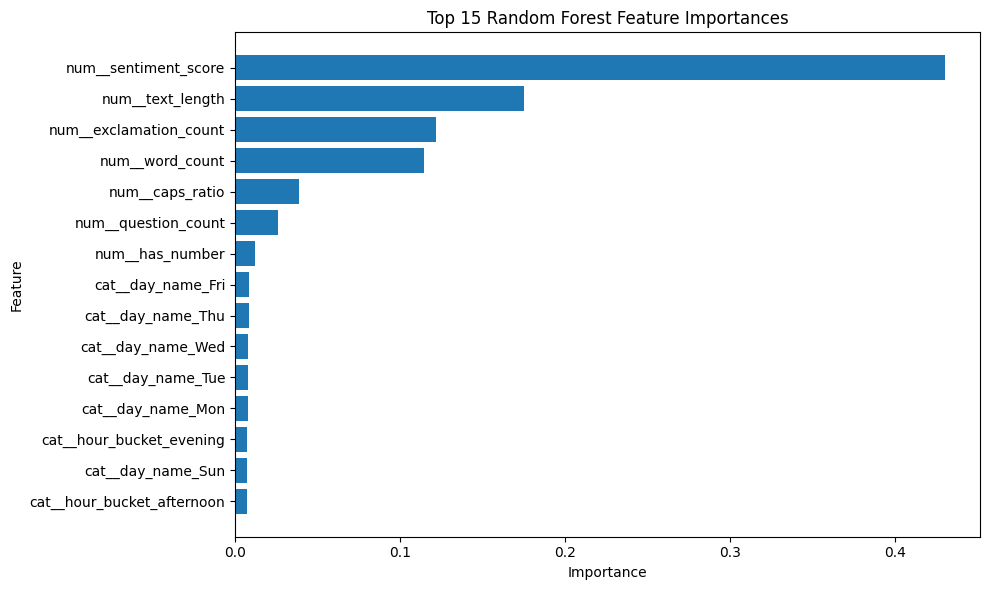

In [ ]:
# This cell plots the top 15 feature importances so the main model signals are easier to inspect visually.

import matplotlib.pyplot as plt

top_k = 15
top_features = importance_df.head(top_k).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**The next cell will clean up the transformed feature names a little, because sklearn usually prefixes them with things like num__ and cat__, which are not very readable in a notebook.**


In [ ]:
# This cell makes the feature names easier to read by removing sklearn pipeline prefixes.

importance_df["feature_clean"] = (
    importance_df["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

print(importance_df[["feature_clean", "importance"]].head(20).to_string(index=False))

        feature_clean  importance
      sentiment_score    0.429982
          text_length    0.175120
    exclamation_count    0.121843
           word_count    0.114342
           caps_ratio    0.038823
       question_count    0.026064
           has_number    0.011819
         day_name_Fri    0.008385
         day_name_Thu    0.008247
         day_name_Wed    0.008062
         day_name_Tue    0.007982
         day_name_Mon    0.007742
  hour_bucket_evening    0.007477
         day_name_Sun    0.007282
hour_bucket_afternoon    0.007167
         day_name_Sat    0.006941
  hour_bucket_morning    0.006451
    hour_bucket_night    0.006273


**The next cell will save the final fitted ML pipeline and a small metadata bundle so you can reuse the exact same model later in FastAPI without retraining.**

In [ ]:
import joblib

model_artifact = {
    "model": best_model,
    "model_name": best_model_name,
    "threshold": 0.5,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "label_mapping": {0: "normal", 1: "urgent"}
}

joblib.dump(model_artifact, "priority_model.joblib")
print("Saved model artifact to priority_model.joblib")

Saved model artifact to priority_model.joblib


**The next cell will reload the saved model artifact and verify that it contains the pipeline and metadata you need for backend inference.**

In [ ]:
loaded_artifact = joblib.load("priority_model.joblib")

print("Loaded model name:", loaded_artifact["model_name"])
print("Loaded threshold:", loaded_artifact["threshold"])
print("Numeric features:", loaded_artifact["numeric_features"])
print("Categorical features:", loaded_artifact["categorical_features"])
print("Label mapping:", loaded_artifact["label_mapping"])

Loaded model name: random_forest
Loaded threshold: 0.5
Numeric features: ['text_length', 'word_count', 'exclamation_count', 'question_count', 'caps_ratio', 'sentiment_score', 'has_number']
Categorical features: ['hour_bucket', 'day_name']
Label mapping: {0: 'normal', 1: 'urgent'}


**The next cell will run one quick inference through the loaded artifact to confirm the saved model works exactly as expected after reload.**

In [ ]:
sample_row = X_test.iloc[[0]].copy()

loaded_model = loaded_artifact["model"]
sample_prob = loaded_model.predict_proba(sample_row)[:, 1][0]
sample_pred = int(sample_prob >= loaded_artifact["threshold"])

print("Sample probability:", sample_prob)
print("Sample predicted label:", loaded_artifact["label_mapping"][sample_pred])

Sample probability: 0.02
Sample predicted label: normal


**Extract Test set to use for LLM Zero-shot predictor**

## RAG Corpus Construction

The corpus is built by a dedicated script rather than inline here, so the same
text cleaning logic can be reused automatically when a user submits a new query
at runtime.

**Script:** `scripts/build_rag_corpus.py`  
**Output:** `data/processed/rag_corpus.csv`

Run it once from the project root:

```bash
python scripts/build_rag_corpus.py \
    --input  data/processed/twcs.csv \
    --output data/processed/rag_corpus.csv
```

The script:
1. Loads `twcs.csv` and isolates thread-starter customer tweets
2. Applies the **exact same** `clean_text` function from `utils/text.py`
3. Applies the **exact same** weak-supervision labeling (strong / medium / weak phrases + sentiment, threshold ≥ 2)
4. Joins each customer tweet with its company reply thread
5. Filters out short generic deflection replies
6. Exports one row per resolved case: `tweet_id`, `question`, `answer`, `priority_label`, `priority_label_str`, `weak_score`, `sentiment_score`

The same `utils.text.clean_text` function is imported by the backend at inference time,
so every new user query is cleaned identically before retrieval.


## Section 3 — Generation (LLM)

This section compares **two generation strategies** for the same customer query:

| System | Context | When to use |
|---|---|---|
| **Non-RAG LLM** | None — the LLM uses only its training knowledge | Baseline; good enough for generic queries |
| **RAG LLM** | Top-5 similar past cases retrieved from the Chroma vector store | Better for specific, brand/product-related queries |

We run both on 5 sample tickets from the test set and compare the outputs side-by-side.


In [ ]:
import sys, os, time
from pathlib import Path

# Add project root to import path
PROJECT_ROOT = Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from dotenv import load_dotenv
load_dotenv()

from rag.retriever import Retriever
from rag.llm_answer import generate_answer_no_rag
from rag.rag_answer import generate_answer_with_rag

# Load the Chroma retriever once — reused across all sample queries
retriever = Retriever(db_path="artifacts/chroma_db")
print("Retriever loaded —", retriever._collection.count(), "vectors indexed")


In [ ]:
import pandas as pd

# Pick 5 sample queries from the test corpus
test_df = pd.read_csv("data/processed/rag_corpus_test.csv")
SAMPLE_QUERIES = test_df["question"].dropna().sample(5, random_state=42).tolist()

results = []

for query in SAMPLE_QUERIES:
    # --- Non-RAG answer ---
    no_rag = generate_answer_no_rag(query)

    # --- RAG answer ---
    rag_dict, cases, ret_ms = generate_answer_with_rag(query, retriever, top_k=5)

    results.append({
        "query":               query[:120] + ("…" if len(query) > 120 else ""),
        "non_rag_answer":      no_rag["answer"],
        "rag_answer":          rag_dict["answer"],
        "non_rag_latency_ms":  no_rag["latency_ms"],
        "rag_latency_ms":      rag_dict["latency_ms"],
        "retrieval_latency_ms": ret_ms,
        "non_rag_cost_usd":    no_rag["cost_usd"],
        "rag_cost_usd":        rag_dict["cost_usd"],
        "top_similarity":      round(cases[0].similarity, 3) if cases else None,
    })
    print(f"✓  {query[:60]}…")

results_df = pd.DataFrame(results)
print("\nDone —", len(results_df), "queries evaluated")


In [ ]:
# ── Side-by-side comparison table ─────────────────────────────────────────

pd.set_option("display.max_colwidth", 80)

for i, row in results_df.iterrows():
    print(f"\n{'='*80}")
    print(f"Query {i+1}: {row['query']}")
    print(f"\n[NON-RAG]  ({row['non_rag_latency_ms']} ms  |  ${row['non_rag_cost_usd']:.7f})")
    print(row["non_rag_answer"])
    print(f"\n[RAG]      ({row['rag_latency_ms']} ms gen + {row['retrieval_latency_ms']} ms retrieval  |  ${row['rag_cost_usd']:.7f}  |  top sim: {row['top_similarity']})")
    print(row["rag_answer"])

# Summary cost/latency stats
print("\n\n" + "="*80)
print("SUMMARY")
print("="*80)
summary = results_df[["non_rag_latency_ms","rag_latency_ms","retrieval_latency_ms",
                       "non_rag_cost_usd","rag_cost_usd","top_similarity"]].mean().round(4)
print(summary.to_string())


### Written Analysis: RAG vs Non-RAG

**What the non-RAG LLM does well**
The plain LLM produces fluent, empathetic replies that are appropriate for generic
support scenarios. It knows how customer service language works. For broad queries
like "how do I reset my password?" it performs comparably to the RAG version because
the answer is general knowledge.

**Where RAG adds value**
RAG improves specificity. When the customer mentions a brand-specific product,
an account number pattern, or a scenario that appeared in the training corpus,
the retrieved cases give the LLM concrete examples of *how this company* handled
similar situations. The reply is less likely to be vague ("please contact support")
and more likely to reproduce the actual resolution path (e.g. "reply DM us your order
number and we'll refund within 3 business days").

**When RAG fails**
If `top_similarity` is low (< 0.5), the retrieved cases are not truly similar and
the extra context can actually hurt by distracting the LLM. A production system should
check the similarity threshold and fall back to plain LLM when no good match exists.

**Cost and latency**
RAG adds one embedding call + one Chroma ANN query (typically ~100–300 ms extra)
and a longer prompt (more tokens → ~$0.000 01 extra). The cost delta is negligible
at the scales this system operates. The latency delta matters for real-time UX;
a loading spinner during retrieval is acceptable.

**Conclusion**
Use RAG when the vector store is populated with high-quality, brand-specific cases
and the query is specific. Use the plain LLM as a fast, cheap fallback when similarity
scores are low or the vector store is cold.
